In [33]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

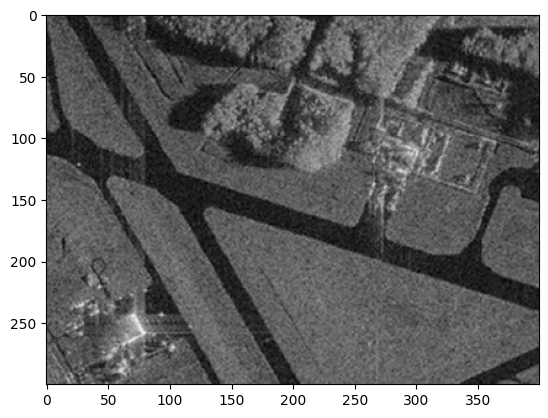

In [34]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.show()

In [35]:
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(mask)
    if abs(av_val - img[point]) <= T:
        return True
    return False

def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    iteration = 0
    
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i,j] == 0 and mask[i - r:i + r + 1, j - r:j + r + 1].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        
        mask += local_mask
    
    return mask * 255

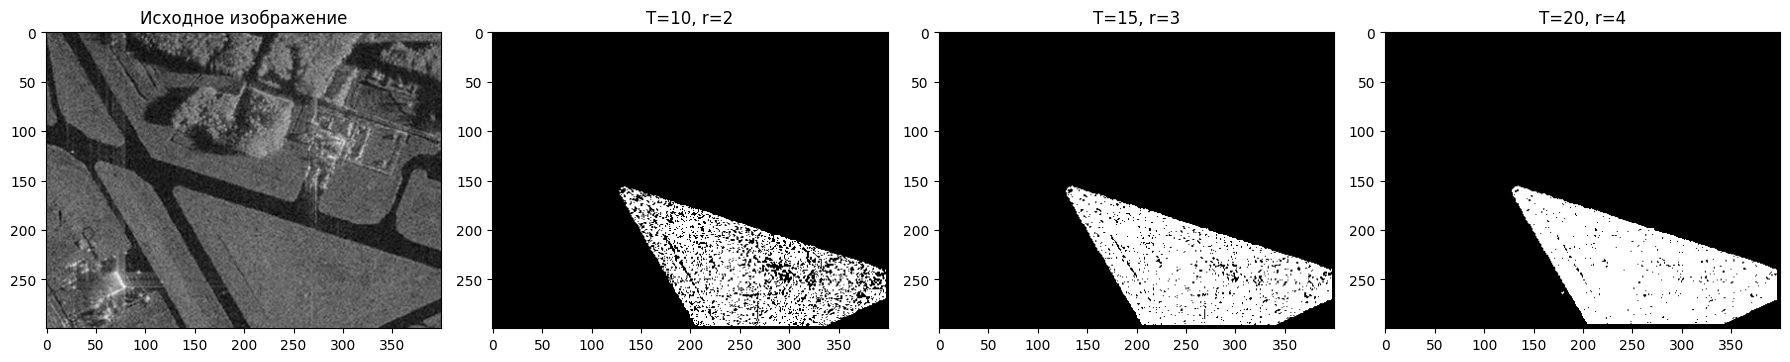

In [36]:
seed_point = (250, 250)

plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.imshow(image_gray, cmap="gray")
plt.title('Исходное изображение')





mask1 = region_growing(image_gray, seed_point, homo_average, 2, 10)
plt.subplot(1, 4, 2)
plt.imshow(mask1, cmap="gray")
plt.title(f'T=10, r=2')



mask2 = region_growing(image_gray, seed_point, homo_average, 3, 15)
plt.subplot(1, 4, 3)
plt.imshow(mask2, cmap="gray")
plt.title(f'T=15, r=3')


mask3 = region_growing(image_gray, seed_point, homo_average, 4, 20)
plt.subplot(1, 4, 4)
plt.imshow(mask3, cmap="gray")
plt.title(f'T=20, r=4')

plt.tight_layout()

plt.show()


In [37]:
def homo_median(img, mask, point, T):
    """Критерий на основе медианы"""
    median_val = np.median(img[mask > 0])
    if abs(median_val - img[point]) <= T:
        return True
    return False


def homo_std_based(img, mask, point, T):
    """Критерий на основе стандартного отклонения"""
    region_pixels = img[mask > 0]
    mean_val = region_pixels.mean()
    std_val = region_pixels.std()
    
    if abs(img[point] - mean_val) <= T * std_val:
        return True
    return False


def homo_percentile(img, mask, point, T):
    """Критерий на основе процентилей"""
    region_pixels = img[mask > 0]
    p25 = np.percentile(region_pixels, 25)
    p75 = np.percentile(region_pixels, 75)
    iqr = p75 - p25
    
    if (img[point] >= p25 - T * iqr) and (img[point] <= p75 + T * iqr):
        return True
    return False

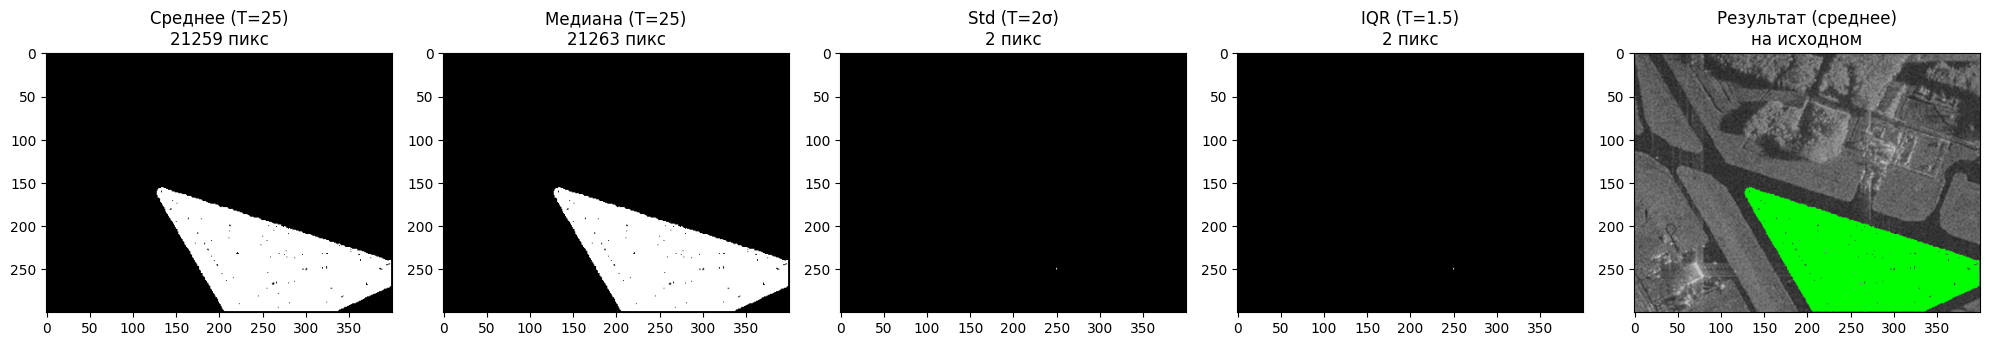

In [38]:
plt.figure(figsize=(20, 5))

seed_point = (250, 250)


# 1. Среднее
mask_avg = region_growing(image_gray, seed_point, homo_average, 1, 25)
plt.subplot(1, 5, 1)
plt.imshow(mask_avg, cmap="gray")
plt.title(f'Среднее (T=25)\n{np.count_nonzero(mask_avg)} пикс')

# 2. Медиана
mask_med = region_growing(image_gray, seed_point, homo_median, 1, 25)
plt.subplot(1, 5, 2)
plt.imshow(mask_med, cmap="gray")
plt.title(f'Медиана (T=25)\n{np.count_nonzero(mask_med)} пикс')

# 3. Стандартное отклонение
mask_std = region_growing(image_gray, seed_point, homo_std_based, 1, 2.0)
plt.subplot(1, 5, 3)
plt.imshow(mask_std, cmap="gray")
plt.title(f'Std (T=2σ)\n{np.count_nonzero(mask_std)} пикс')

# 4. Процентили
mask_perc = region_growing(image_gray, seed_point, homo_percentile, 1, 1.5)
plt.subplot(1, 5, 4)
plt.imshow(mask_perc, cmap="gray")
plt.title(f'IQR (T=1.5)\n{np.count_nonzero(mask_perc)} пикс')

# 5. Наложение на исходное изображение (лучший результат)
plt.subplot(1, 5, 5)
overlay = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2BGR)
overlay[mask_avg > 0] = [0, 255, 0]
plt.imshow(overlay)
plt.title('Результат (среднее)\nна исходном')

plt.tight_layout()

plt.show()



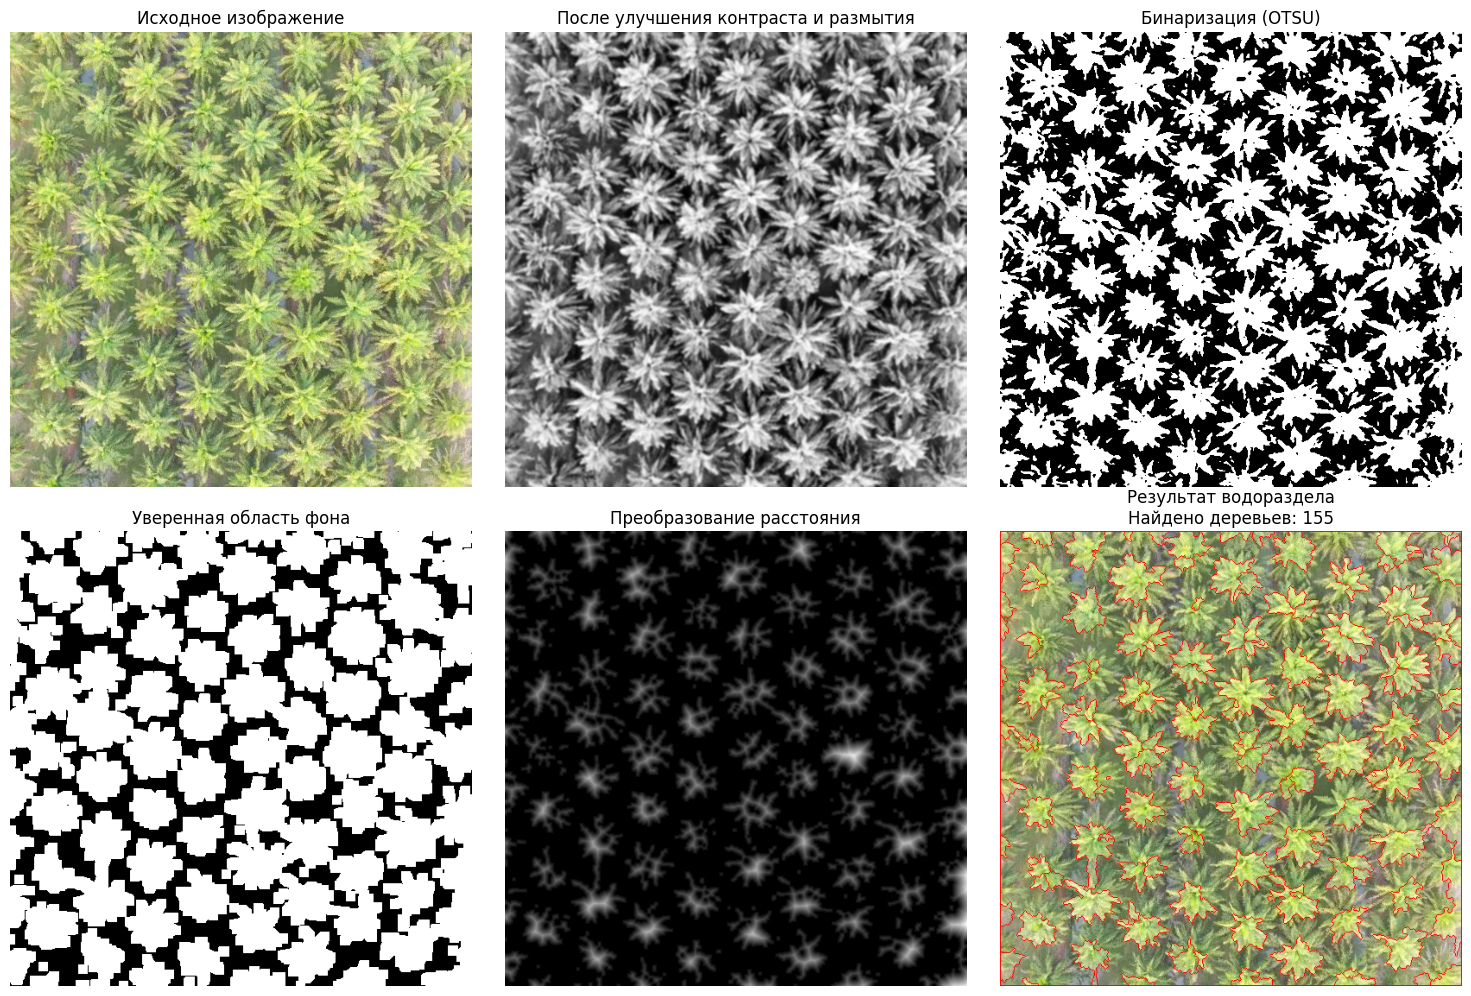

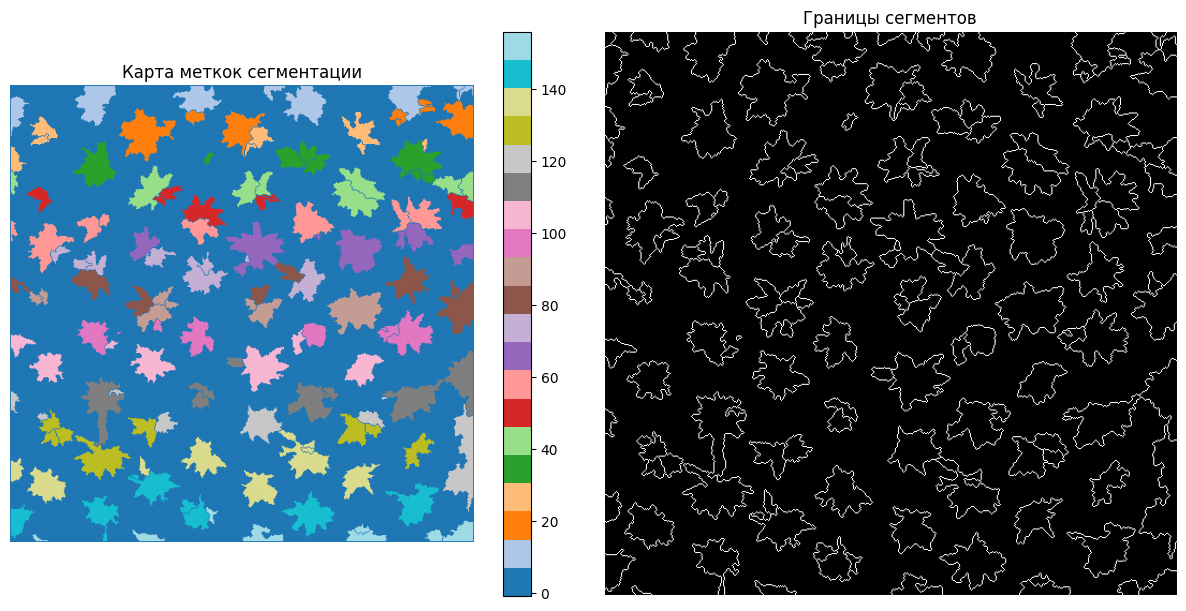

Количество обнаруженных пальмовых деревьев: 155


In [39]:
image1 = cv2.imread('palm_1.jpg')
image_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image_gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title('Исходное изображение')
plt.axis('off')


clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
image_enhanced = clahe.apply(image_gray1)


blurred = cv2.GaussianBlur(image_enhanced, (5, 5), 0)

plt.subplot(2, 3, 2)
plt.imshow(blurred, cmap='gray')
plt.title('После улучшения контраста и размытия')
plt.axis('off')


ret, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.subplot(2, 3, 3)
plt.imshow(thresh, cmap='gray')
plt.title('Бинаризация (OTSU)')
plt.axis('off')


kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)


sure_bg = cv2.dilate(opening, kernel, iterations=3)

plt.subplot(2, 3, 4)
plt.imshow(sure_bg, cmap='gray')
plt.title('Уверенная область фона')
plt.axis('off')


dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.3 * dist_transform.max(), 255, 0)

plt.subplot(2, 3, 5)
plt.imshow(dist_transform, cmap='gray')
plt.title('Преобразование расстояния')
plt.axis('off')


sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)


ret, markers = cv2.connectedComponents(sure_fg)


markers = markers + 1


markers[unknown == 255] = 0


markers = cv2.watershed(image_rgb, markers)


result_image = image_rgb.copy()
result_image[markers == -1] = [255, 0, 0]  


unique_markers = np.unique(markers)
tree_count = len(unique_markers) - 2  

plt.subplot(2, 3, 6)
plt.imshow(result_image)
plt.title(f'Результат водораздела\nНайдено деревьев: {tree_count}')
plt.axis('off')

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.imshow(markers, cmap='tab20')
plt.title('Карта меткок сегментации')
plt.colorbar()
plt.axis('off')


plt.subplot(1, 2, 2)
boundaries = np.zeros_like(image_gray1)
boundaries[markers == -1] = 255
plt.imshow(boundaries, cmap='gray')
plt.title('Границы сегментов')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Количество обнаруженных пальмовых деревьев: {tree_count}")